In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")


with open("without early stopping.json") as f:
    data_wo = json.load(f)

with open("with early stopping.json") as f:
    data_w = json.load(f)


def to_df(data, label):
    rows = []
    for method, models in data.items():
        for model, episodes in models.items():
            for ep, metrics in episodes.items():
                rows.append({
                    "dataset": label,
                    "method": method,
                    "model": model,
                    "episode": int(ep),
                    "angular_error": metrics.get("angular_error", 0),
                    "distance_error": metrics.get("distance_error", 0),
                    "success": metrics.get("success", 0),
                })
    return pd.DataFrame(rows)

df_wo = to_df(data_wo, "without_ES")
df_w = to_df(data_w, "with_ES")
df = pd.concat([df_wo, df_w], ignore_index=True)

# Cleaner labels for plots
df["dataset"] = df["dataset"].map({
    "without_ES": "Without ES",
    "with_ES": "With ES"
})


#  AGGREGATIONS
agg_method = df.groupby(["dataset", "method"])[["angular_error","distance_error","success"]].mean().reset_index()
agg_model = df.groupby(["dataset", "method", "model"])[["angular_error","distance_error","success"]].mean().reset_index()
agg_episode = df.groupby(["dataset", "episode"])[["angular_error","distance_error","success"]].mean().reset_index()


#  1. METHOD COMPARISON (SINGLE PLOT)
for metric in ["angular_error", "distance_error", "success"]:
    plt.figure(figsize=(10,5), dpi=300)

    sns.barplot(
        data=agg_method,
        x="method",
        y=metric,
        hue="dataset"
    )

    plt.title(f"Method Comparison ({metric})")
    plt.xticks(rotation=20)
    plt.legend()
    plt.tight_layout()

    plt.savefig(f"combined_method_{metric}.png", dpi=300)
    plt.show()


#  2. MODEL COMPARISON (SINGLE PLOT)
for metric in ["angular_error", "distance_error", "success"]:
    plt.figure(figsize=(12,5), dpi=300)

    sns.barplot(
        data=agg_model,
        x="model",
        y=metric,
        hue="dataset",
        errorbar=None
    )

    plt.title(f"Model Comparison ({metric})")
    plt.xticks(rotation=20)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"combined_model_{metric}.png", dpi=300)
    plt.show()


#  3. EPISODE TREND (SINGLE LINE PLOT)
for metric in ["angular_error", "distance_error", "success"]:
    plt.figure(figsize=(10,5), dpi=300)

    sns.lineplot(
        data=agg_episode,
        x="episode",
        y=metric,
        hue="dataset",
        marker="o"
    )

    plt.title(f"Episode Trend ({metric})")
    plt.legend()
    plt.tight_layout()

    plt.savefig(f"combined_episode_{metric}.png", dpi=300)
    plt.show()


#  4. SCATTER (OPTIONAL - STILL GOOD)
plt.figure(figsize=(8,6), dpi=300)

sns.scatterplot(
    data=df,
    x="angular_error",
    y="distance_error",
    hue="dataset",
    style="method",
    alpha=0.7
)

plt.title("Angular vs Distance Error")
plt.tight_layout()
plt.savefig("scatter_errors.png", dpi=300)
plt.show()




#  5. IMPROVEMENT PLOT
diff = agg_method.pivot(index="method", columns="dataset", values="success")

diff["Improvement (With ES - Without ES)"] = diff["With ES"] - diff["Without ES"]

plt.figure(figsize=(8,5), dpi=300)
sns.barplot(x=diff.index, y=diff["Improvement (With ES - Without ES)"])

plt.title("Improvement Due to Early Stopping")
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig("improvement_success.png", dpi=300)
plt.show()


print("Done")

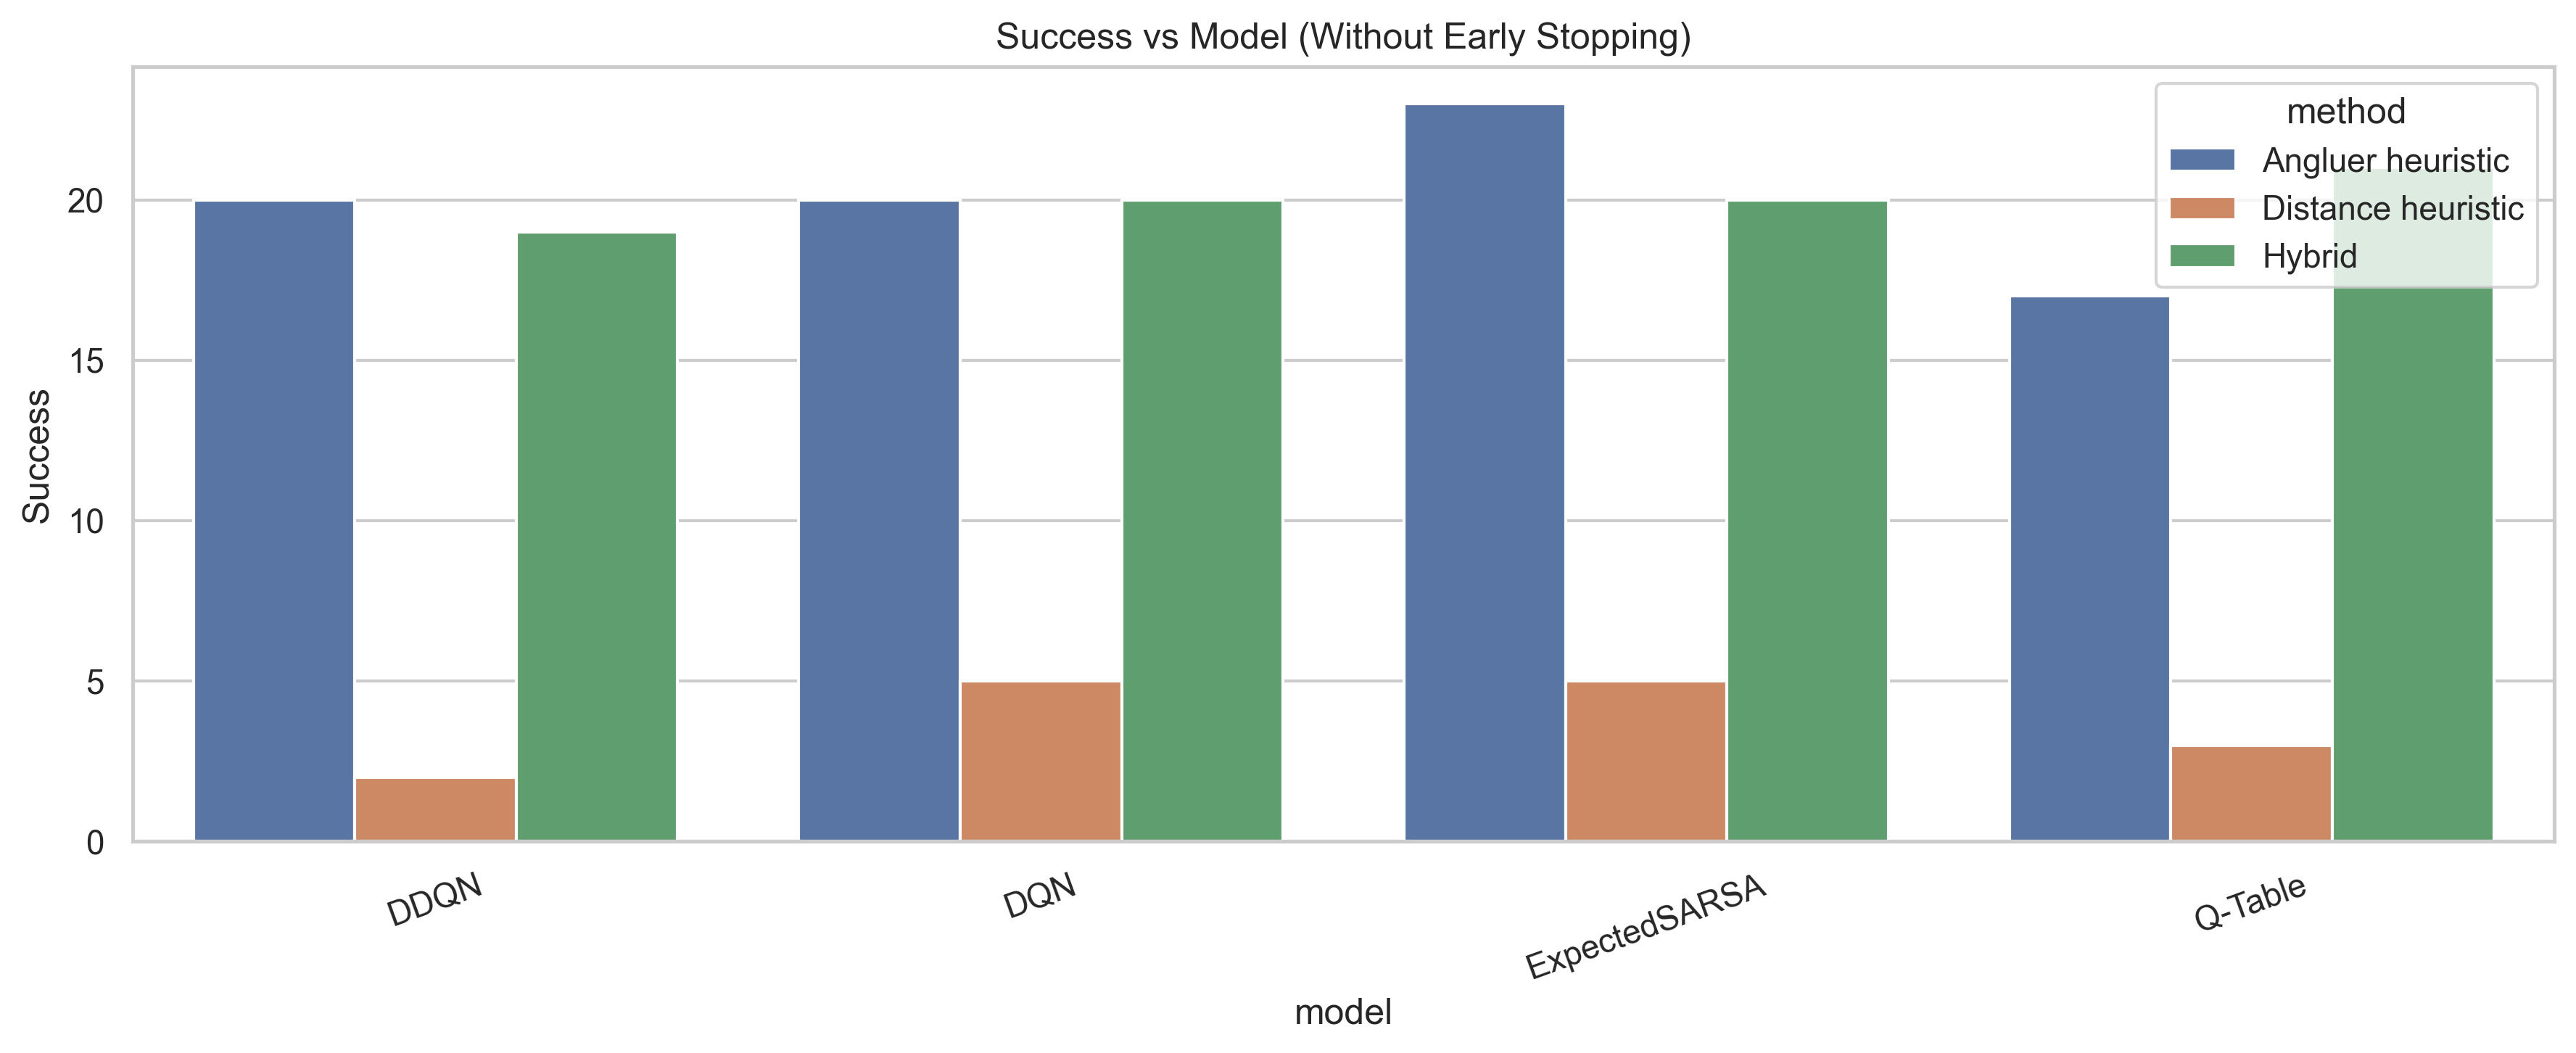

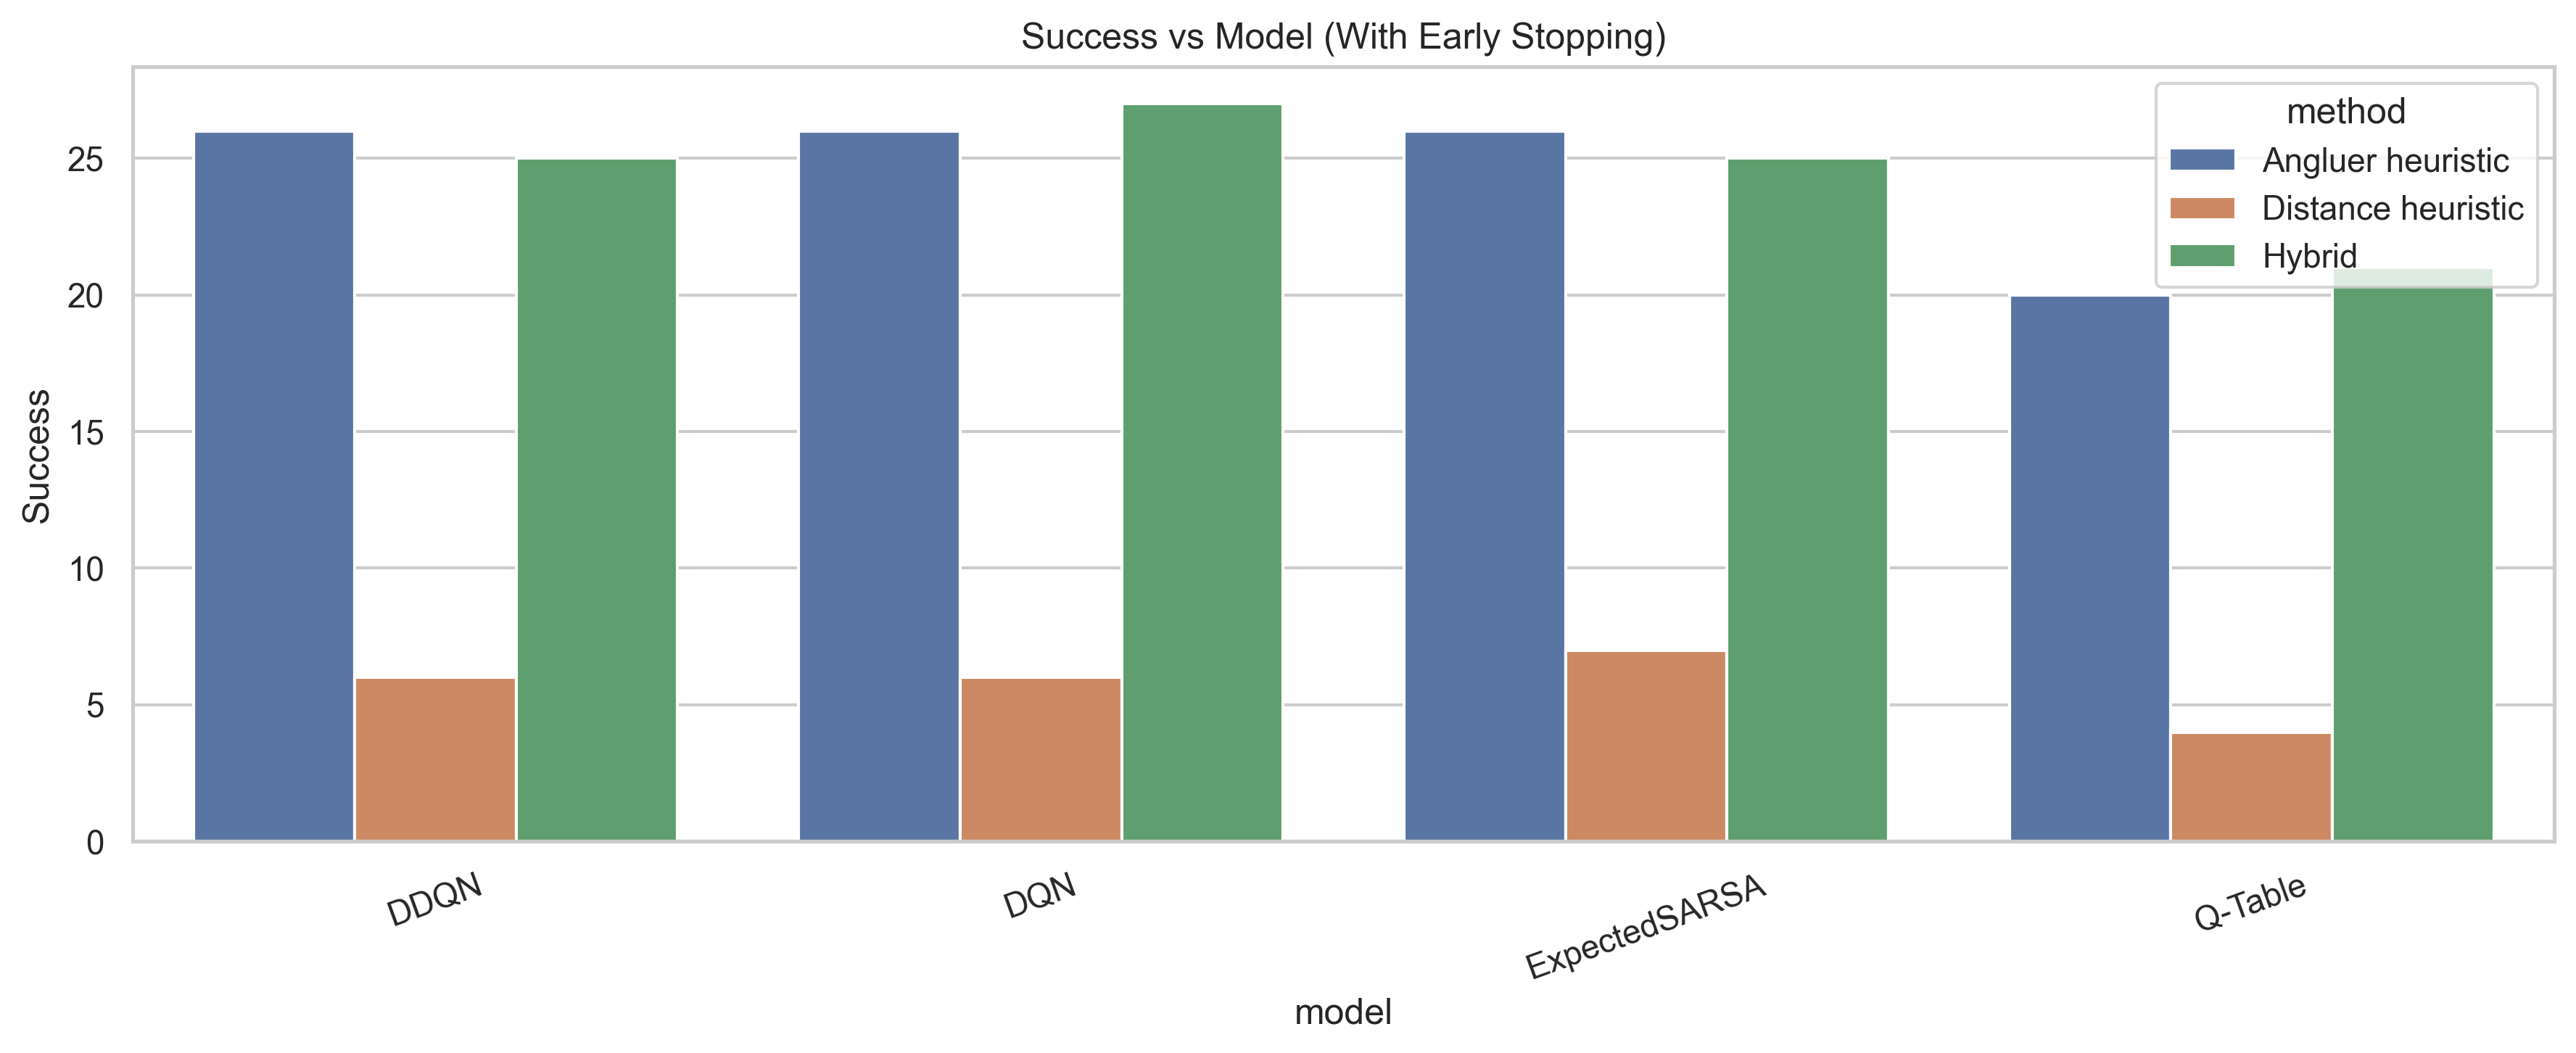

In [ ]:
# OPTIONAL: filter only episode 6
df_plot = df[df["episode"] == 6]   # remove if not needed

# AGGREGATE
agg_plot = df_plot.groupby(["dataset", "model", "method"])["success"].mean().reset_index()

# SPLIT DATA
df_without = agg_plot[agg_plot["dataset"] == "Without ES"]
df_with = agg_plot[agg_plot["dataset"] == "With ES"]


# --------- PLOT 1: WITHOUT ES ---------
plt.figure(figsize=(12,5), dpi=300)

sns.barplot(
    data=df_without,
    x="model",
    y="success",
    hue="method"
)

plt.title("Success vs Model (Without Early Stopping)")
plt.xticks(rotation=20)
plt.ylabel("Success")
plt.tight_layout()

plt.savefig("success_models_without_es.png", dpi=300)
plt.show()


# --------- PLOT 2: WITH ES ---------
plt.figure(figsize=(12,5), dpi=300)

sns.barplot(
    data=df_with,
    x="model",
    y="success",
    hue="method"
)

plt.title("Success vs Model (With Early Stopping)")
plt.xticks(rotation=20)
plt.ylabel("Success")
plt.tight_layout()

plt.savefig("success_models_with_es.png", dpi=300)
plt.show()

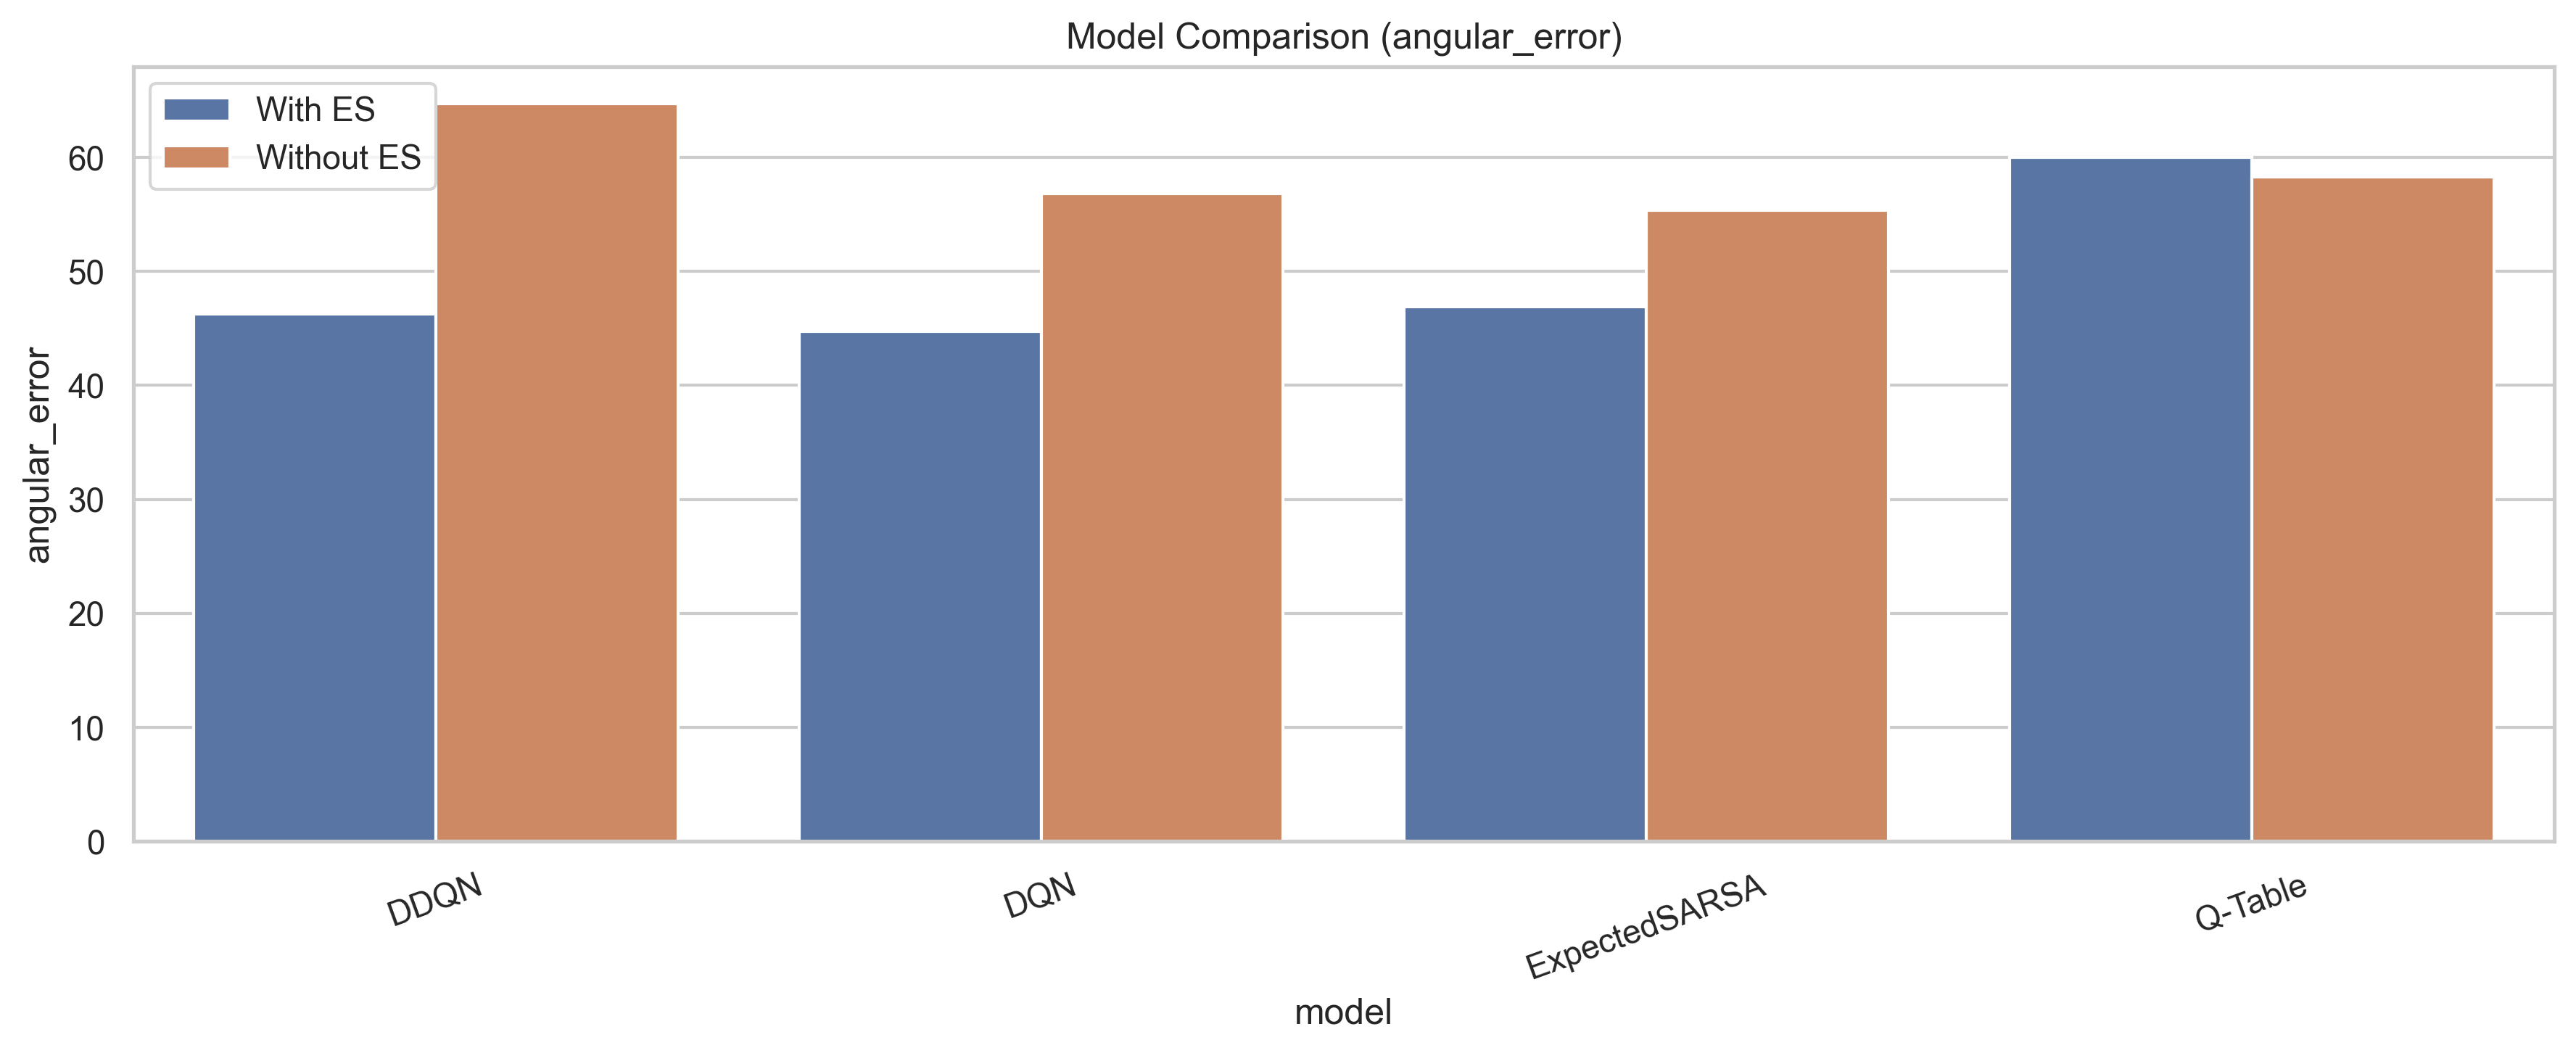

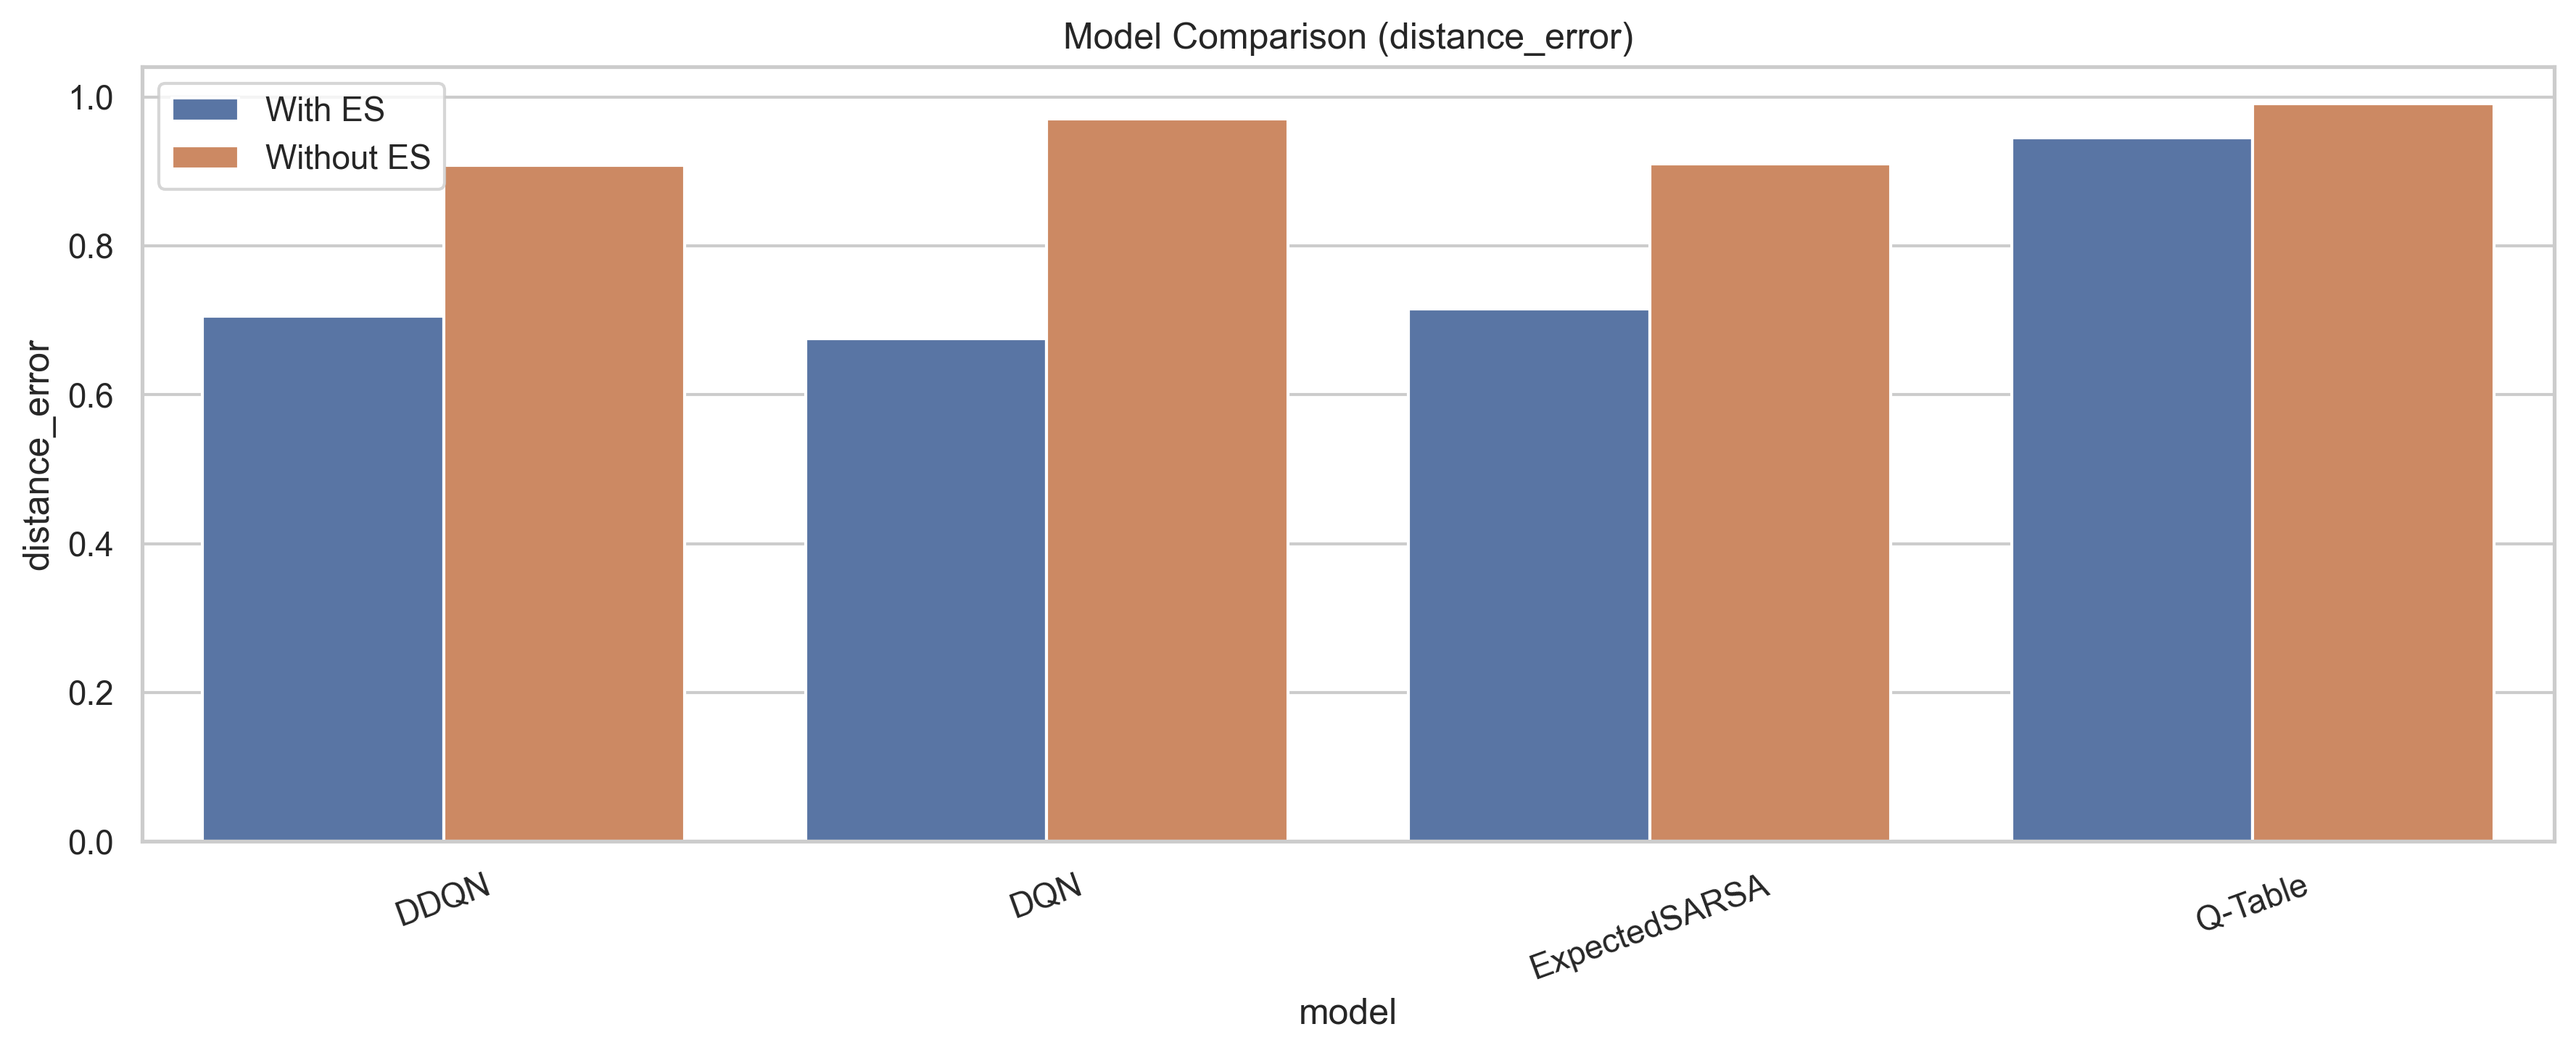

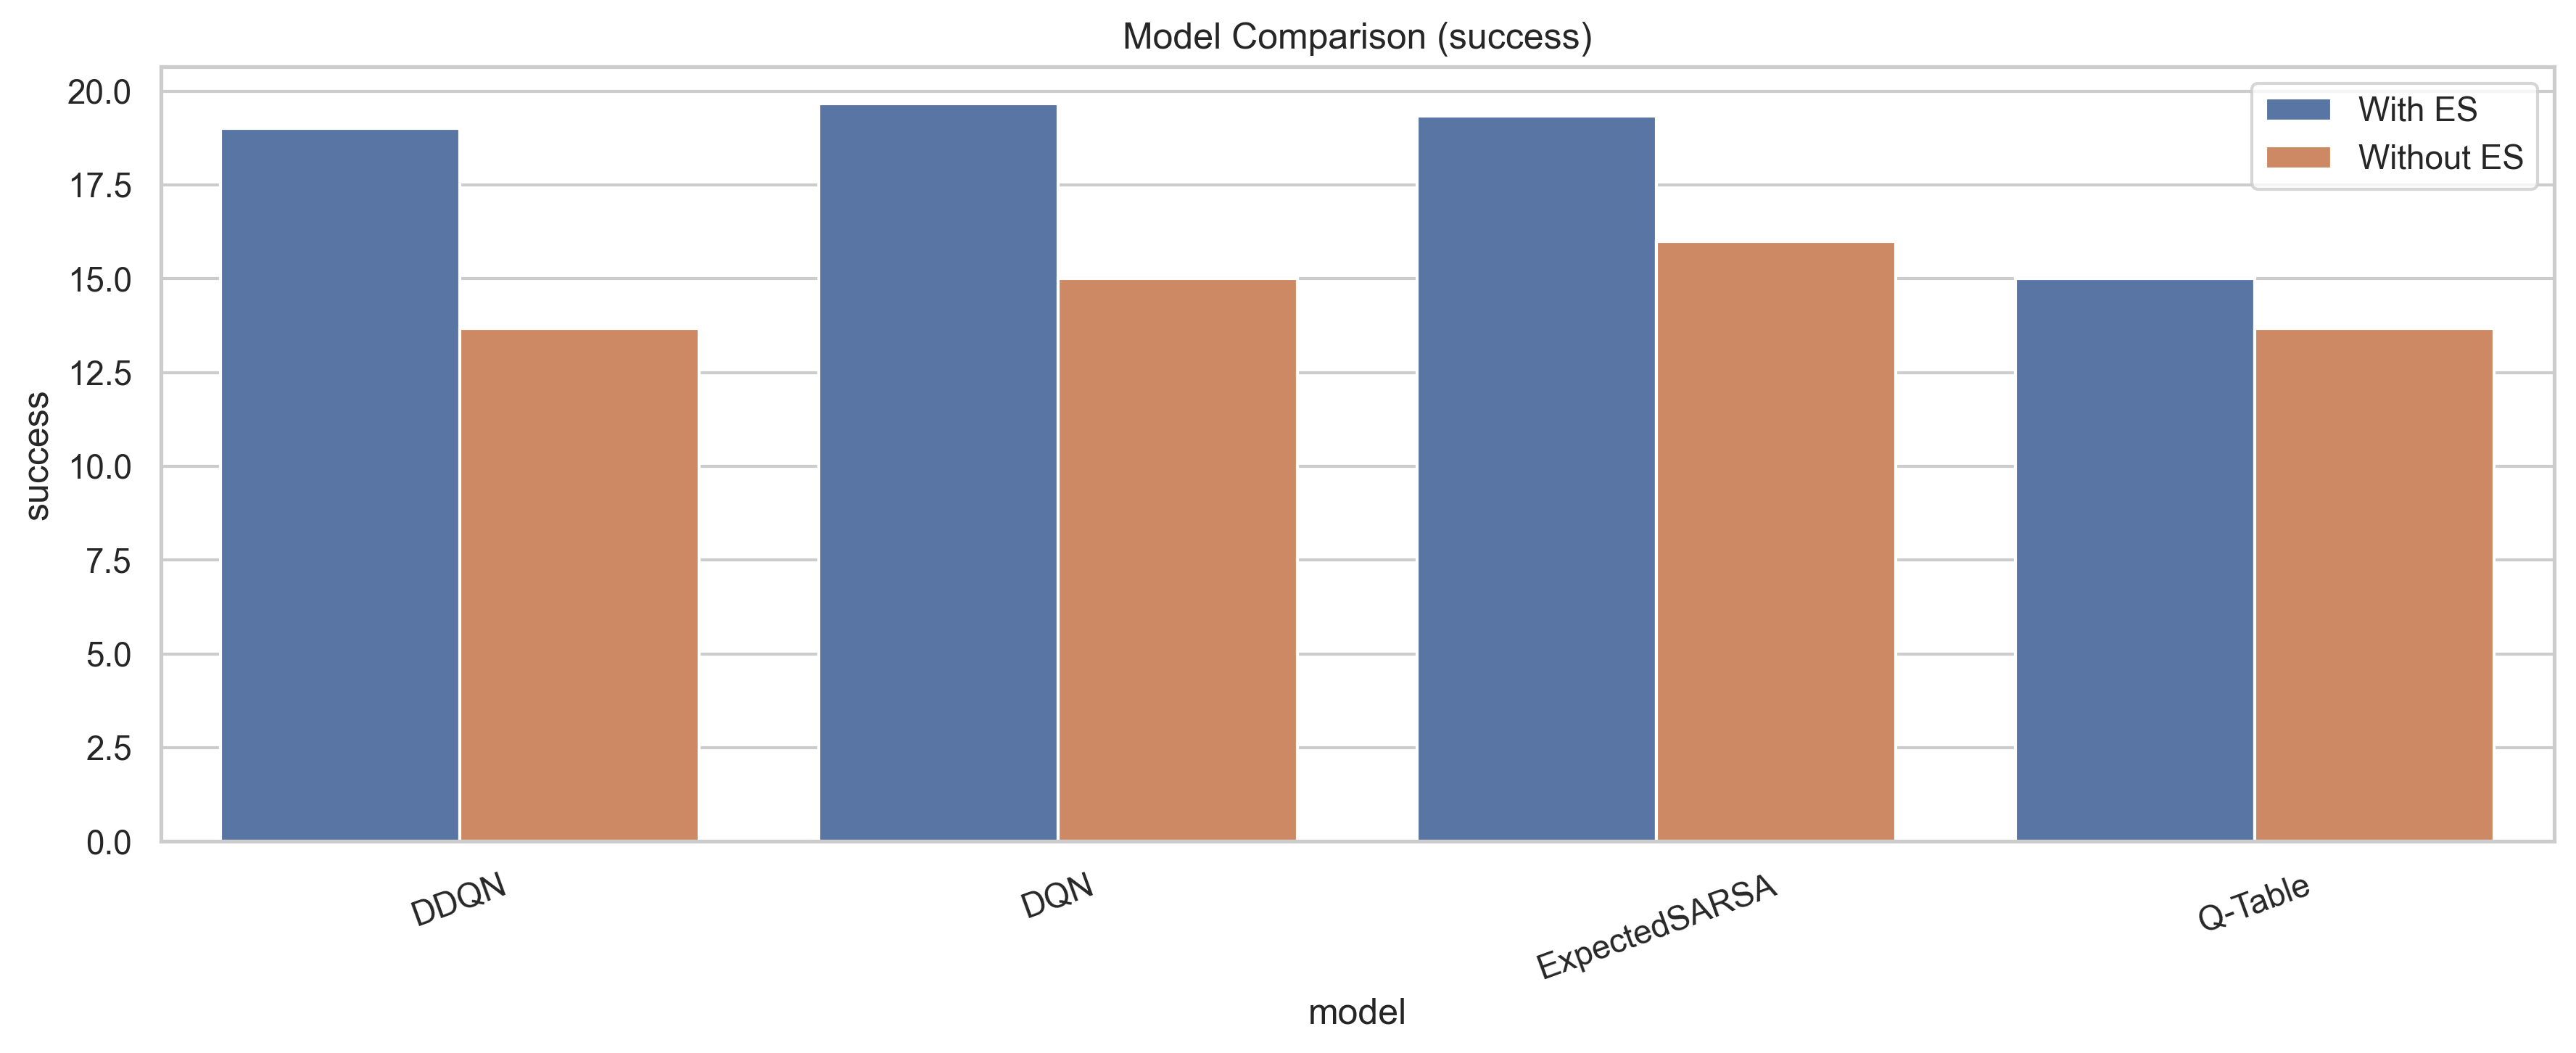

In [ ]:
df_ep6 = df[df["episode"] == 6]


agg_method = df_ep6.groupby(["dataset", "method"])[["angular_error","distance_error","success"]].mean().reset_index()
agg_model = df_ep6.groupby(["dataset", "method", "model"])[["angular_error","distance_error","success"]].mean().reset_index()
agg_episode = df_ep6.groupby(["dataset", "episode"])[["angular_error","distance_error","success"]].mean().reset_index()

for metric in ["angular_error", "distance_error", "success"]:
    plt.figure(figsize=(12,5), dpi=300)

    sns.barplot(
        data=agg_model,
        x="model",
        y=metric,
        hue="dataset",
        errorbar=None
    )

    plt.title(f"Model Comparison ({metric})")
    plt.xticks(rotation=20)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"for_ep6combined_model_{metric}.png", dpi=300)
    plt.show()
